# Linear Advection Equation in 1D with DG and SIAC Postprocessing

This notebook studies the one-dimensional linear advection equation

$$
u_t + a u_x = 0, \qquad x \in \Omega,
$$

with constant advection speed $a$. We use a discontinuous Galerkin (DG) method in space, explicit time stepping, and later apply SIAC postprocessing to the computed DG solution.

The main goals are:

- construct a modal DG approximation using orthonormal Legendre basis functions,
- evolve the solution using explicit time integrators such as Forward Euler and RK4,
- study the effect of noise in the DG approximation,
- apply SIAC postprocessing and compare filtered and unfiltered solutions.

## DG Weak Formulation

Let the domain be divided into cells

$$
I_j = [x_{j-\frac12}, x_{j+\frac12}],
$$

and map each cell to the reference interval $r \in [-1,1]$. On each cell, the DG approximation is written as

$$
u_h^j(x(r),t)
=
\sum_{n=0}^p u_n^j(t)\,\ell_n(r),
$$

where $\{\ell_n\}_{n=0}^p$ is an orthonormal Legendre basis on $[-1,1]$.

Multiplying the advection equation by a test function $v_h$, integrating over one cell, and integrating the flux term by parts gives

$$
\int_{I_j} (u_h)_t v_h \, dx
-
\int_{I_j} a u_h (v_h)_x \, dx
+
\widehat{f}_{j+\frac12} v_h^-
-
\widehat{f}_{j-\frac12} v_h^+
=
0.
$$

Here $\widehat{f}$ is a numerical flux. In this notebook we initially use the Lax--Friedrichs flux

$$
\widehat{f}(u^-,u^+)
=
\frac12\left(a u^- + a u^+\right)
-
\frac12 |a|\left(u^+ - u^-\right),
$$

which reduces to the standard upwind flux for linear advection.

## Time Stepping and CFL Condition

After spatial discretization, the DG method gives a system of ordinary differential equations

$$
\frac{d\mathbf{u}}{dt} = L(\mathbf{u}),
$$

where $L$ is the DG spatial operator.

We consider explicit time stepping methods such as Forward Euler and classical fourth-order Runge--Kutta (RK4). For a uniform mesh with cell size $h$, polynomial degree $p$, and advection speed $a$, we use the practical CFL estimate

$$
\Delta t
\leq
C_{\mathrm{CFL}}
\frac{h}{(2p+1)|a|}.
$$

The constants used here are conservative, non-spectral-radius-based choices. They are intended as safe defaults rather than sharp stability limits.

Typical choices are:

$$
C_{\mathrm{CFL}} =
\begin{cases}
0.5, & \text{Forward Euler}, \\
1.0, & \text{RK4}.
\end{cases}
$$

In the experiments below, an additional safety factor may be applied, and the time step is adjusted so that the final time is reached exactly.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.mesh import build_uniform_mesh
from src.projection import l2_project_mesh
from src.dg_solver import dg_rhs_advection
from src.time_integrators import forward_euler_step, rk4_step, time_integrator
from src.cfl import estimate_dt_advection, choose_time_step
from src.evaluation import evaluate_dg_solution
from src.metrics import linf_error, l2_error_dg, relative_l2_error_dg, relative_l2_error_from_grid
from src.siac import apply_siac_to_modal_dg_1d

In [ ]:
# Wave speed
a = 2

# Total Time
T = 2

# time stepping method: rk4 or euler (forward_euler)
time_method = "rk4"

# Define the domain
xmin, xmax = -1, 1
domain = (-1, 1)

# DG setup
p = 2
order = p + 1
K = 32

# Exact function (periodic)
def exact_func(x):
    return np.sin(2*np.pi*x)

# create mesh
mesh = build_uniform_mesh(K=K, domain=domain)

# build initial projection
dg = l2_project_mesh(f=exact_func, p=p, mesh=mesh, num_quad=None)

# Define RHS wrapper
def rhs(u, t):
    return dg_rhs_advection(
        coeffs=u, 
        mesh=mesh, 
        p=p, 
        a=a
    )

# choose time stepping from CFL conditions
dt_est = estimate_dt_advection(mesh=mesh, p=p, a=a, method=time_method, safety=0.9)
dt, num_steps = choose_time_step(T=T, dt_est=dt_est)

print(f"dt = {dt}")
print(f"num_steps = {num_steps}")



dt = 0.0056179775280898875
num_steps = 356


In [4]:
time_tol = 1e-12

u = dg["coeffs"].copy()
t = 0.0

for n in range(num_steps):
    dt_step = min(dt, T - t)

    if dt_step <= time_tol:
        break

    u = time_integrator(rhs, u, t, dt_step, method=time_method)
    t += dt_step

# Snap final time to T if only roundoff remains
if abs(T - t) <= time_tol:
    t = T
else:
    raise RuntimeError(f"Time stepping stopped at t={t}, not T={T}.")

dg_final = dg.copy()
dg_final["coeffs"] = u
dg_final["t"] = t

In [5]:

# number of evaluation points per element/cell
ppe = 20

eval_grid, U_dg = evaluate_dg_solution(dg_final, points_per_cell=ppe)

t_final = dg_final["t"]

def exact_solution(x, t):
    return exact_func(x - a*t)

U_exact = exact_solution(eval_grid, t_final)

In [6]:

# pointwise Linf using plotting/evaluation grid
err_linf = linf_error(U_dg, U_exact)

# quadrature-based L2 errors
err_l2 = l2_error_dg(dg_final, exact_solution, t=dg_final["t"])
err_l2_rel = relative_l2_error_dg(dg_final, exact_solution, t=dg_final["t"])

print(f"Linf error       = {err_linf:.3e}")
print(f"L2 error         = {err_l2:.3e}")
print(f"Relative L2 error = {err_l2_rel:.3e}")

Linf error       = 9.807e-04
L2 error         = 2.972e-04
Relative L2 error = 2.972e-04


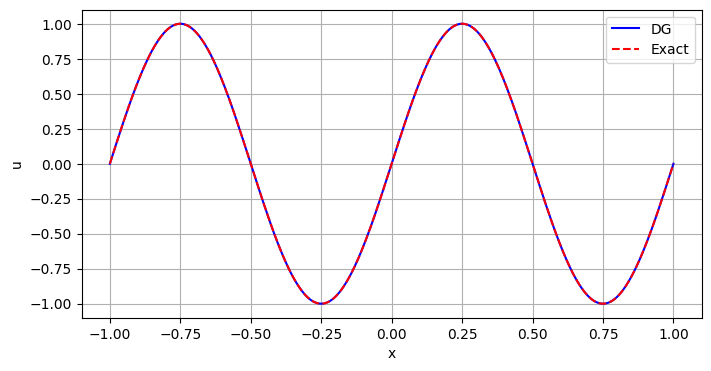

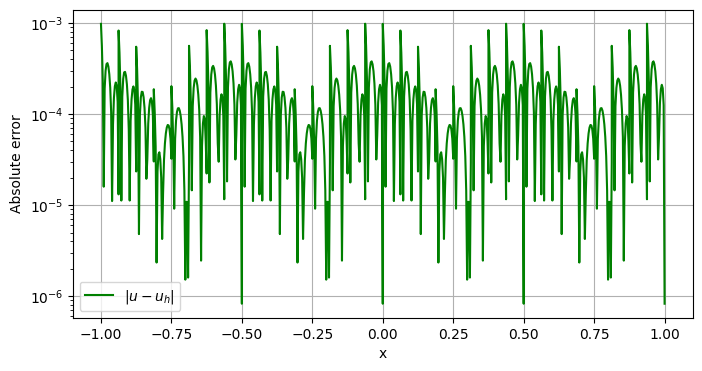

In [7]:


plt.figure(figsize=(8, 4))
plt.plot(eval_grid, U_dg, "b", label="DG")
plt.plot(eval_grid, U_exact, "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()

abs_error = np.abs(U_dg - U_exact)

plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid, abs_error, "g", label=r"$|u-u_h|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()

### SIAC Postprocessor

After computing the DG solution $u_h$, we apply a SIAC postprocessor by convolving the DG approximation with a compactly supported kernel. The filtered solution is written as

$$
u_h^\star(x) = (K_H \ast u_h)(x)
= \int_{\mathbb{R}} K_H(x-y)u_h(y)\,dy.
$$

The scaled kernel is defined by

$$
K_H(x) = \frac{1}{H}K\left(\frac{x}{H}\right),
$$

where $H>0$ controls the physical width of the filter. The reference SIAC kernel is constructed as a linear combination of shifted B-splines,

$$
K(x)
=
\sum_{\gamma \in \mathcal{I}} c_\gamma B_n(x-\gamma),
$$

where $B_n$ is a cardinal B-spline of degree/order $n$, $\mathcal{I}$ is a finite stencil of shifts, and the coefficients $c_\gamma$ are chosen to enforce polynomial reproduction.

Polynomial reproduction means that convolution with the kernel leaves polynomials of degree at most $r$ unchanged:

$$
K \ast q = q,
\qquad
\forall q \in \mathbb{P}_r.
$$

This is enforced through the moment conditions

$$
\int_{\mathbb{R}} K(z)z^m\,dz
=
\delta_{m0},
\qquad
m=0,1,\ldots,r.
$$

In the initial experiments, we use a symmetric periodic SIAC filter. Boundary-aware or one-sided SIAC filters can be added later for non-periodic problems.

#### Current scaling convention

For now, the SIAC postprocessor is implemented only for the standard scaling $H=h$, where $h$ is the uniform mesh size. In this case the filter stencil aligns naturally with neighboring DG cells. Extensions to arbitrary scalings $H=\lambda h$ will require rescaling the kernel argument and adjusting the stencil width, and are left for a later version.

In [8]:
# Postprocessor
moments = 2*p   # Must be even
BSorder = p+1

U_star = apply_siac_to_modal_dg_1d(dg=dg_final, moments=moments, BSorder=BSorder, points_per_cell=ppe)

In [9]:
# slice all to interior for valid comparison
halfker = int(np.ceil((moments + BSorder) / 2))

# Only valid in interior
start = halfker * ppe
stop = (K - halfker) * ppe

eval_grid_int = eval_grid[start:stop]
U_dg_int = U_dg[start:stop]
U_exact_int = U_exact[start:stop]
U_star_int = U_star[start:stop]

In [10]:

# pointwise Linf using plotting/evaluation grid
err_linf_U = linf_error(U_dg_int, U_exact_int)
err_linf_Ustar = linf_error(U_star_int, U_exact_int)

print(f"Linf error u       = {err_linf_U:.3e}")
print(f"Linf error u_star  = {err_linf_Ustar:.3e}")

Linf error u       = 9.807e-04
Linf error u_star  = 4.466e-05


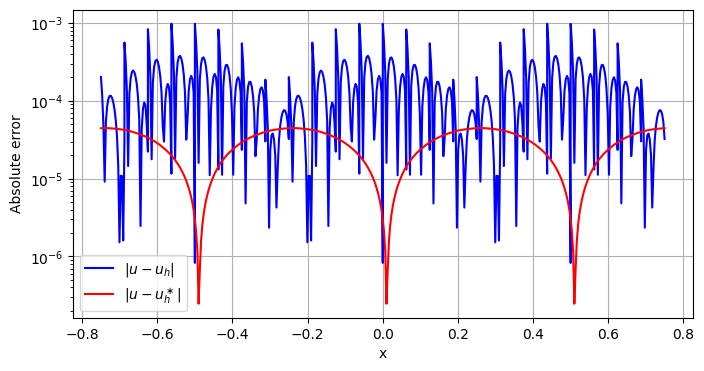

In [11]:
# pointwise error
abs_error_u = np.abs(U_dg_int - U_exact_int)
abs_error_ustar = np.abs(U_star_int - U_exact_int)


plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid_int, abs_error_u, "b", label=r"$|u-u_h|$")
plt.semilogy(eval_grid_int, abs_error_ustar, "r", label=r"$|u-u_h^\ast|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()

### Convergence and Error Study over Mesh Sizes

The convergence of the DG method should be 
$$
    \mathcal{O}(h^{p+1})
$$
and for the SIAC postprocessed solution
$$
    \mathcal{O}(h^{2p+1})
$$

In [ ]:
from src.helpers import run_dg_siac_advection_experiment

K_values = [16, 32, 64, 128, 256]
ppe_base = 20
K_max = max(K_values)

results = []
errors = []

K_values = [16, 32, 64, 128]
K_max = max(K_values)
ppe_base = 20

results = []
errors = []

for K in K_values:
    if K_max % K != 0:
        raise ValueError(f"K={K} does not divide K_max={K_max}.")

    ppe = ppe_base * (K_max // K)

    result = run_dg_siac_advection_experiment(
        K=K,
        p=p,
        a=a,
        T=T,
        domain=domain,
        exact_func=exact_func,
        time_method=time_method,
        ppe=ppe,
        cfl_safety=0.9,
        moments=2*p,
        BSorder=p+1,
    )

    err_linf_U = linf_error(
        result["U_dg_int"],
        result["U_exact_int"],
    )

    err_linf_Ustar = linf_error(
        result["U_star_int"],
        result["U_exact_int"],
    )

    err_l2_U = relative_l2_error_from_grid(
        result["U_dg_int"],
        result["U_exact_int"],
        result["eval_grid_int"],
    )

    err_l2_Ustar = relative_l2_error_from_grid(
        result["U_star_int"],
        result["U_exact_int"],
        result["eval_grid_int"],
    )

    results.append(result)

    errors.append({
        "K": K,
        "h": result["mesh"]["h"],
        "ppe": ppe,
        "dt": result["dt"],
        "num_steps": result["num_steps"],
        "Linf_DG": err_linf_U,
        "Linf_SIAC": err_linf_Ustar,
        "L2_DG_grid": err_l2_U,
        "L2_SIAC_grid": err_l2_Ustar,
    })

error_df = pd.DataFrame(errors)

error_df["rate_Linf_DG"] = np.nan
error_df["rate_Linf_SIAC"] = np.nan

error_df.loc[1:, "rate_Linf_DG"] = np.log(error_df["Linf_DG"].values[:-1] / error_df["Linf_DG"].values[1:]) / np.log(2)

error_df.loc[1:, "rate_Linf_SIAC"] = np.log(error_df["Linf_SIAC"].values[:-1] / error_df["Linf_SIAC"].values[1:]) / np.log(2)


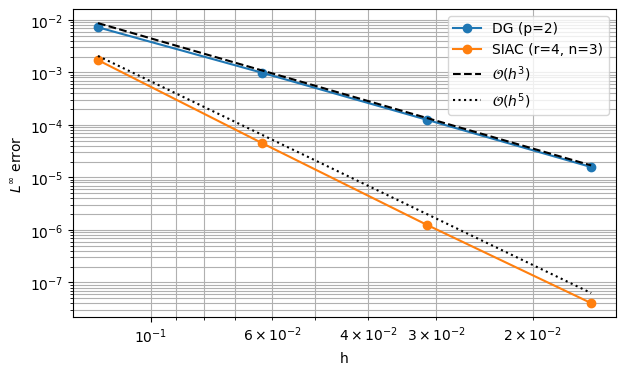

In [19]:
h = error_df["h"].to_numpy()
err_dg = error_df["Linf_DG"].to_numpy()
err_siac = error_df["Linf_SIAC"].to_numpy()

q_dg = p + 1
q_siac = 2*p + 1

# Reference lines anchored near the first data point, then offset
ref_dg = err_dg[0] * (h / h[0])**q_dg * 1.2
ref_siac = err_siac[0] * (h / h[0])**q_siac * 1.2


plt.figure(figsize=(7, 4))

plt.loglog(h, err_dg, "o-", label=f"DG (p={p})")
plt.loglog(h, err_siac, "o-", label=f"SIAC (r={moments}, n={BSorder})")

plt.loglog(h, ref_dg, "k--", label=rf"$\mathcal{{O}}(h^{{{q_dg}}})$")
plt.loglog(h, ref_siac, "k:", label=rf"$\mathcal{{O}}(h^{{{q_siac}}})$")

plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel(r"$L^\infty$ error")
plt.legend()
plt.grid(True, which="both")
plt.show()

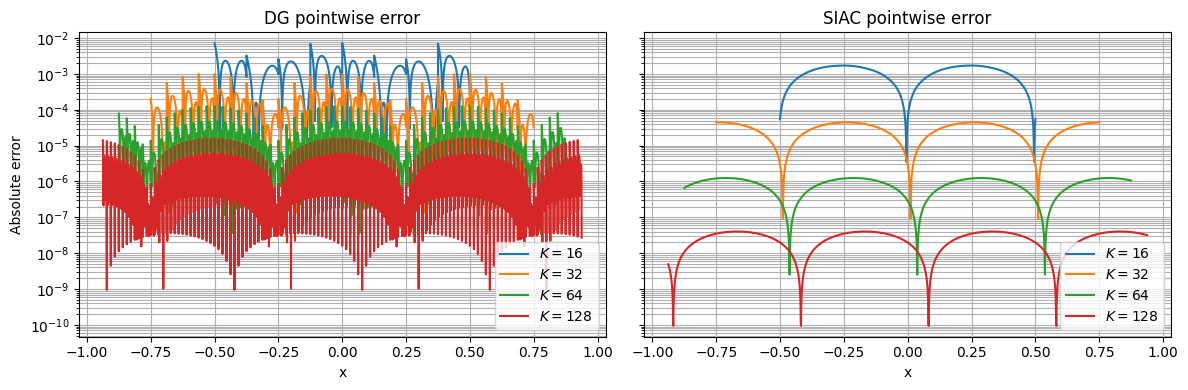

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax_dg, ax_siac = axes

# Collect global y-limits across both DG and SIAC errors
all_errors = []

for result in results:
    e_dg = np.abs(result["U_dg_int"] - result["U_exact_int"])
    e_siac = np.abs(result["U_star_int"] - result["U_exact_int"])

    all_errors.append(e_dg)
    all_errors.append(e_siac)

    K = result["K"]

    ax_dg.semilogy(
        result["eval_grid_int"],
        e_dg,
        label=rf"$K={K}$",
    )

    ax_siac.semilogy(
        result["eval_grid_int"],
        e_siac,
        label=rf"$K={K}$",
    )

# Shared y-axis scale
all_errors = np.concatenate(all_errors)
positive_errors = all_errors[all_errors > 0]

ymin = positive_errors.min()
ymax = positive_errors.max()

ax_dg.set_ylim(0.5 * ymin, 2.0 * ymax)
ax_siac.set_ylim(0.5 * ymin, 2.0 * ymax)

ax_dg.set_title("DG pointwise error")
ax_siac.set_title("SIAC pointwise error")

ax_dg.set_xlabel("x")
ax_siac.set_xlabel("x")

ax_dg.set_ylabel("Absolute error")

ax_dg.grid(True, which="both")
ax_siac.grid(True, which="both")

ax_dg.legend()
ax_siac.legend()

plt.tight_layout()
plt.show()